<a href="https://colab.research.google.com/github/sourav-014/SCT_ML_1/blob/main/House_Price_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# House Price Prediction with Linear Regression

**Goal:** Predict `SalePrice` using only three predictors:
1. **Square footage** (above-ground living area → `GrLivArea`)
2. **Number of bedrooms** (→ `BedroomAbvGr`)
3. **Number of bathrooms** (`FullBath` + 0.5 × `HalfBath`, combined)

**Dataset:** Kaggle "House Prices - Advanced Regression Techniques"
(`train.csv` has `SalePrice`, `test.csv` is the unlabeled Kaggle hold-out set)


In [37]:
# ----------------------------- IMPORTS --------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline
sns.set_style("whitegrid")

## 1. Load the Data

In [38]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("Train shape:", train.shape)
print("Test shape :", test.shape)
train.head()

Train shape: (1460, 81)
Test shape : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. Feature Engineering\n\nThe raw dataset doesn't have one single \"bathrooms\" column, so we combine full and half bathrooms into one feature (a half bath counts as 0.5). We also rename columns to match the project brief.

In [39]:
train['TotalBathrooms'] = train['FullBath'] + 0.5 * train['HalfBath']
test['TotalBathrooms'] = test['FullBath'] + 0.5 * test['HalfBath']

train = train.rename(columns={'GrLivArea': 'SquareFootage', 'BedroomAbvGr': 'Bedrooms'})
test = test.rename(columns={'GrLivArea': 'SquareFootage', 'BedroomAbvGr': 'Bedrooms'})

features = ['SquareFootage', 'Bedrooms', 'TotalBathrooms']
target = 'SalePrice'

X = train[features]
y = train[target]

print("Missing values in selected features (train):")
print(X.isnull().sum())

Missing values in selected features (train):
SquareFootage     0
Bedrooms          0
TotalBathrooms    0
dtype: int64


## 3. Exploratory Data Analysis

Correlation with SalePrice:
SquareFootage     0.708624
Bedrooms          0.168213
TotalBathrooms    0.597966
SalePrice         1.000000
Name: SalePrice, dtype: float64


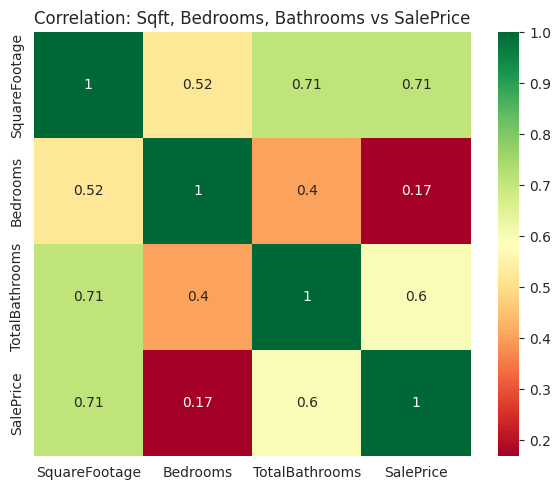

In [40]:
corr_with_price = train[features + [target]].corr()[target]
print("Correlation with SalePrice:")
print(corr_with_price)

plt.figure(figsize=(6, 5))
sns.heatmap(train[features + [target]].corr(), annot=True, cmap="RdYlGn")
plt.title("Correlation: Sqft, Bedrooms, Bathrooms vs SalePrice")
plt.tight_layout()
plt.show()

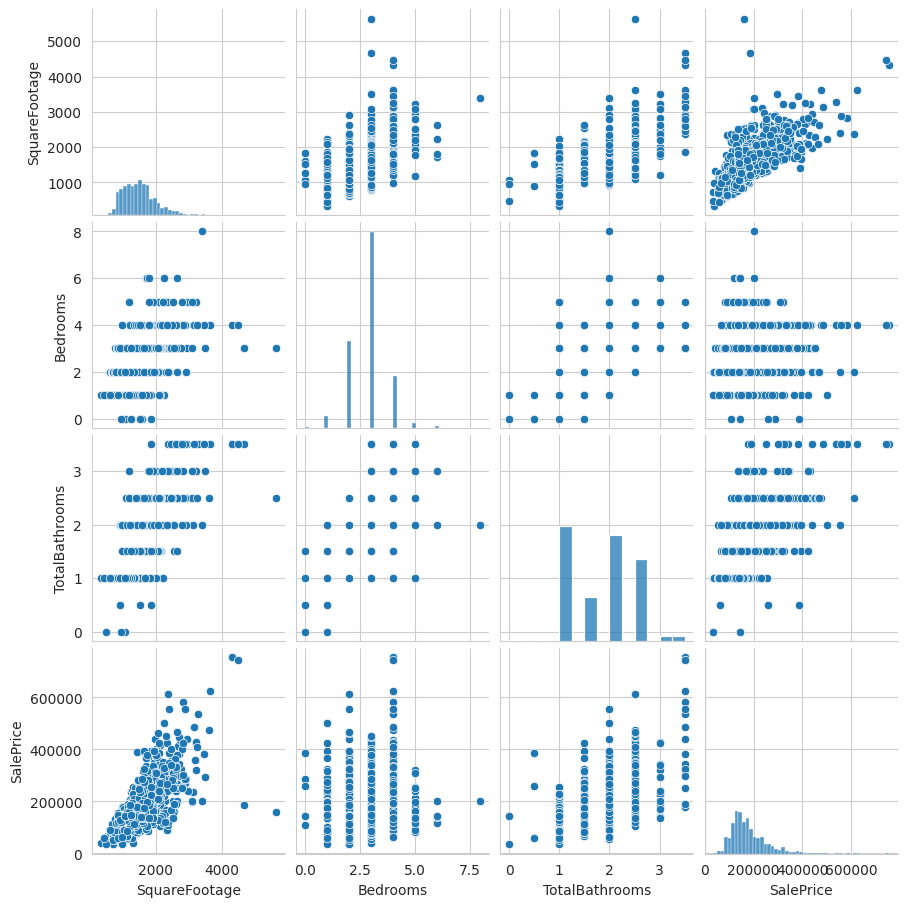

In [41]:
sns.pairplot(train[features + [target]], height=2.3)
plt.show()

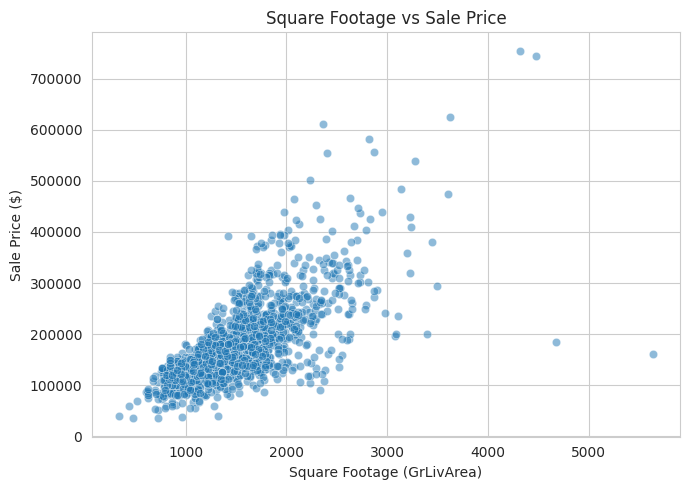

In [42]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=train['SquareFootage'], y=train['SalePrice'], alpha=0.5)
plt.title("Square Footage vs Sale Price")
plt.xlabel("Square Footage (GrLivArea)")
plt.ylabel("Sale Price ($)")
plt.tight_layout()
plt.show()

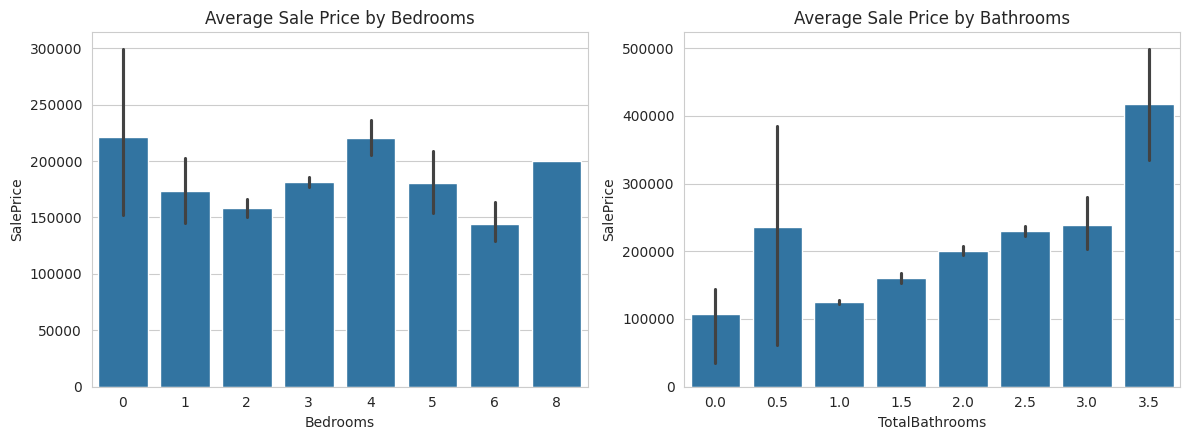

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(x=train['Bedrooms'], y=train['SalePrice'], ax=axes[0])
axes[0].set_title("Average Sale Price by Bedrooms")
sns.barplot(x=train['TotalBathrooms'], y=train['SalePrice'], ax=axes[1])
axes[1].set_title("Average Sale Price by Bathrooms")
plt.tight_layout()
plt.show()

## 4. Outlier Removal

A couple of very large houses in this dataset sold for surprisingly low prices (a documented quirk of this Kaggle dataset). They distort a simple linear fit, so we remove them before training.

In [44]:
outliers = train[(train['SquareFootage'] > 4000) & (train['SalePrice'] < 300000)]
print(f"Removing {len(outliers)} known outlier(s) with SquareFootage > 4000 and SalePrice < 300000")

train_clean = train.drop(outliers.index)

X = train_clean[features]
y = train_clean[target]

Removing 2 known outlier(s) with SquareFootage > 4000 and SalePrice < 300000


## 5. Train / Test Split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows :", X_test.shape[0])

Training rows: 1166
Testing rows : 292


## 6. Train the Model

In [46]:
model = LinearRegression()
model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

## 7. Actual vs Predicted Comparison Table

In [47]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": test_pred
})
comparison["Difference"] = comparison["Actual"] - comparison["Predicted"]
comparison.head(15)

,Actual,Predicted,Difference
1322,190000,244247.428178,-54247.428178
837,100000,136649.084647,-36649.084647
413,115000,133045.919913,-18045.919913
522,159000,201172.331006,-42172.331006
1036,315500,228932.524257,86567.475743
615,137500,102917.410715,34582.589285
218,311500,230330.870195,81169.129805
1032,310000,255697.753711,54302.246289
1289,281000,250431.364259,30568.635741
887,135500,156518.356537,-21018.356537


## 8. Evaluation Metrics

In [48]:
def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {label} ---")
    print("MAE :", round(mae, 2))
    print("MSE :", round(mse, 2))
    print("RMSE:", round(rmse, 2))
    print("R2  :", round(r2, 4))
    print()
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

train_metrics = evaluate(y_train, train_pred, "Training set")
test_metrics = evaluate(y_test, test_pred, "Testing set")

--- Training set ---
MAE : 35270.76
MSE : 2340814066.02
RMSE: 48381.96
R2  : 0.6406

--- Testing set ---
MAE : 37257.11
MSE : 2502370714.45
RMSE: 50023.7
R2  : 0.547



## 9. Cross-Validation\n\nA more robust check than a single train/test split — splits the training data into 5 chunks, trains/tests 5 times, and averages the result.

In [49]:
cv_scores = cross_val_score(model, X_train, y_train,
                             scoring="neg_mean_squared_error", cv=5)
cv_rmse = np.sqrt(-cv_scores)

print("Cross-validation RMSE scores:", cv_rmse)
print("Average CV RMSE:", round(cv_rmse.mean(), 2))

Cross-validation RMSE scores: [45577.46037175 50715.72850721 47148.83026842 52340.66191008
 46773.24207038]
Average CV RMSE: 48511.18


## 10. Model Coefficients

In [50]:
print("Intercept:", round(model.intercept_, 2))
for name, coef in zip(features, model.coef_):
    print(f"{name}: {coef:.2f}")

Intercept: 46892.26
SquareFootage: 131.57
Bedrooms: -33549.41
TotalBathrooms: 17995.32


**Interpretation:**
- `SquareFootage` coefficient → expected \$ change in price per additional sq ft, holding bedrooms and bathrooms constant.
- `Bedrooms` coefficient → expected \$ change in price per additional bedroom, holding square footage and bathrooms constant. This can be small or even *negative* — adding a bedroom without adding space usually means smaller rooms, which buyers don't necessarily pay more for.
- `TotalBathrooms` coefficient → expected \$ change in price per additional bathroom, holding the other two features constant.

## 11. Residual Plot\n\nGood model = points scattered randomly around the red line at 0. A clear pattern/curve/funnel shape means the model is missing something.

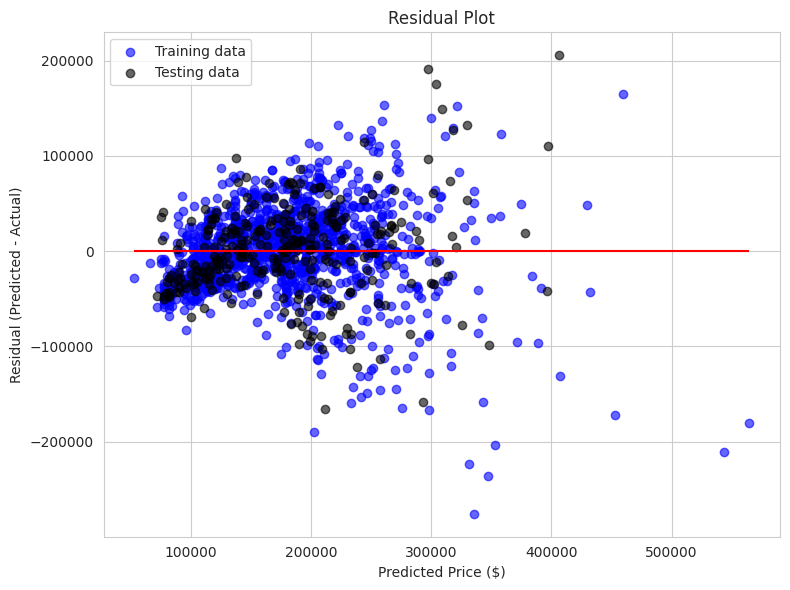

In [51]:
plt.figure(figsize=(8, 6))
plt.scatter(train_pred, train_pred - y_train, c="blue", label="Training data", alpha=0.6)
plt.scatter(test_pred, test_pred - y_test, c="black", label="Testing data", alpha=0.6)
plt.title("Residual Plot")
plt.xlabel("Predicted Price ($)")
plt.ylabel("Residual (Predicted - Actual)")
plt.legend(loc="upper left")
plt.hlines(y=0, xmin=min(train_pred.min(), test_pred.min()),
           xmax=max(train_pred.max(), test_pred.max()), color="red")
plt.tight_layout()
plt.show()

## 12. Predicted vs Actual Plot

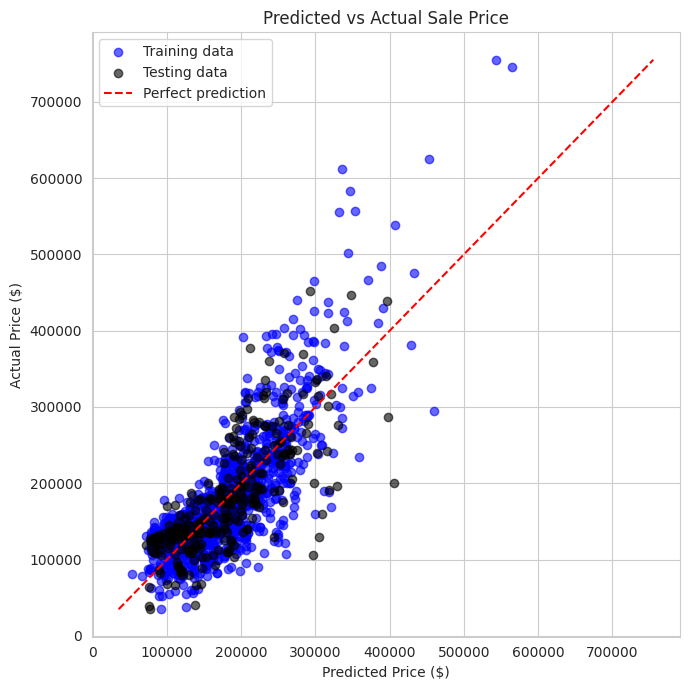

In [52]:
plt.figure(figsize=(7, 7))
plt.scatter(train_pred, y_train, c="blue", label="Training data", alpha=0.6)
plt.scatter(test_pred, y_test, c="black", label="Testing data", alpha=0.6)

lims = [min(y.min(), train_pred.min()), max(y.max(), train_pred.max())]
plt.plot(lims, lims, c="red", linestyle="--", label="Perfect prediction")

plt.title("Predicted vs Actual Sale Price")
plt.xlabel("Predicted Price ($)")
plt.ylabel("Actual Price ($)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 13. Retrain on Full Data, Predict on Kaggle's Real test.csv\n\nRefit on 100% of `train.csv` (not just 80%) before generating predictions for houses with no known `SalePrice`.

In [53]:
final_model = LinearRegression()
final_model.fit(X, y)

X_kaggle_test = test[features].copy()
print("Missing values in Kaggle test.csv (before filling):")
print(X_kaggle_test.isnull().sum())

for col in features:
    if X_kaggle_test[col].isnull().sum() > 0:
        X_kaggle_test[col] = X_kaggle_test[col].fillna(X[col].median())

kaggle_predictions = final_model.predict(X_kaggle_test)

# Linear regression can occasionally output a negative price for extreme
# inputs -- clip at a sane floor since a house can't sell for < $0.
kaggle_predictions = np.clip(kaggle_predictions, a_min=1000, a_max=None)

Missing values in Kaggle test.csv (before filling):
SquareFootage     0
Bedrooms          0
TotalBathrooms    0
dtype: int64


## 14. Build Submission File

In [54]:
submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": kaggle_predictions
})
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv")
submission.head()

Saved submission.csv


,Id,SalePrice
0,1461,116743.290637
1,1462,149048.163210
2,1463,206384.361896
3,1464,203276.434003
4,1465,184522.127043
